# Linear Regression 이란

- https://easy.prag-ai.com/slide/img02/1

### 경력과 연봉의 관계를 분석하여, 경력이 주어졌을때 연봉을 예측하려 한다.

데이터를 살펴보니, 아래와 같은 그래프로 나왔다고 가정했을 때,

 ### 아래 그림처럼, 해당 분포를 만족하는 직선을 찾으려 하는것이 목표다

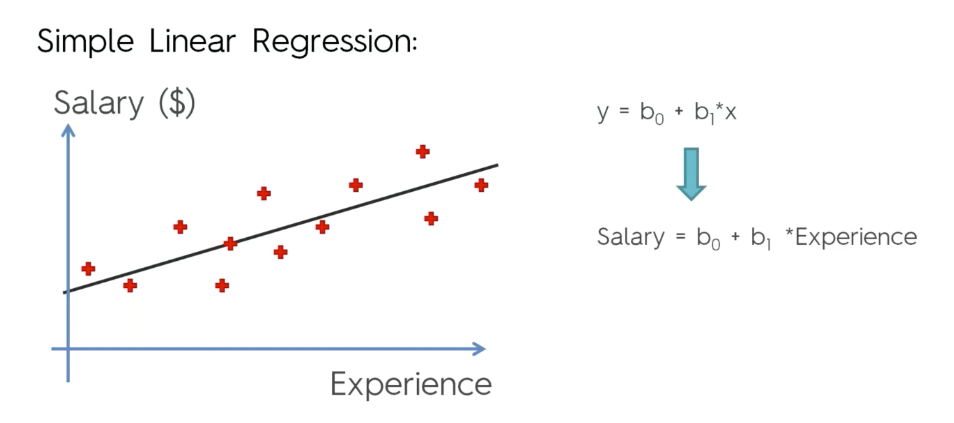

#### 직선을 찾기 위해서는, 우리가 잘 아는 직선의 방정식을 이용하여, 직선의 기울기와 y절편을 구하면 되는것이다.

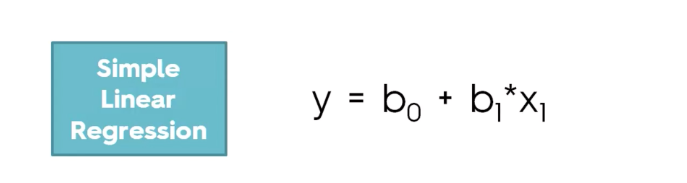

### 여기에서 주의!  x, y 가 우리에게 데이터셋으로 주어졌다. 따라서 우리는 b 를 찾아야 하는것이다.

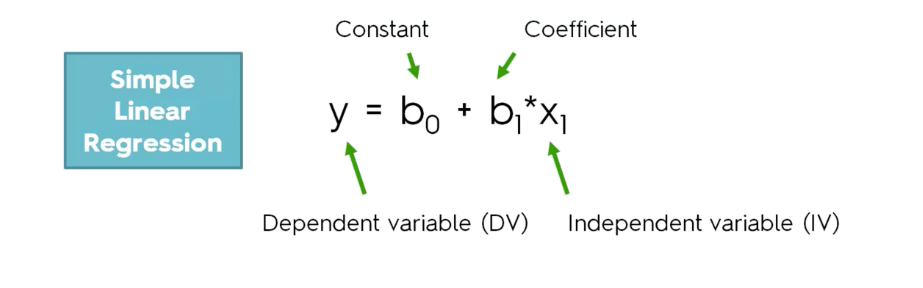

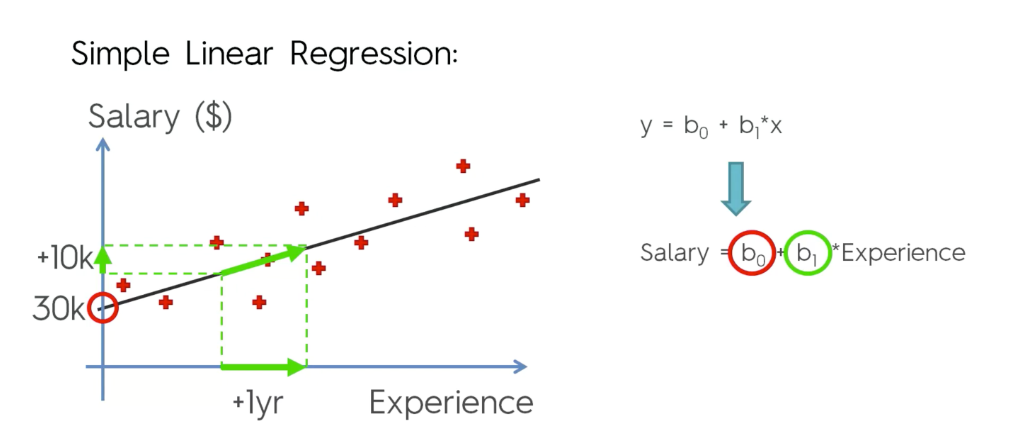

# 즉, 가장 best한 b0, b1 의 값을 찾아 가는 과정을 학습이라고 부른다!


# 그렇다면 학습이란? => 바로 error(오차)를 줄여 나가는 것이다.


아래는 오차를 나타낸다. 그렇다면 오차란? 그리고 직선은 처음에 어디서 가져오지?

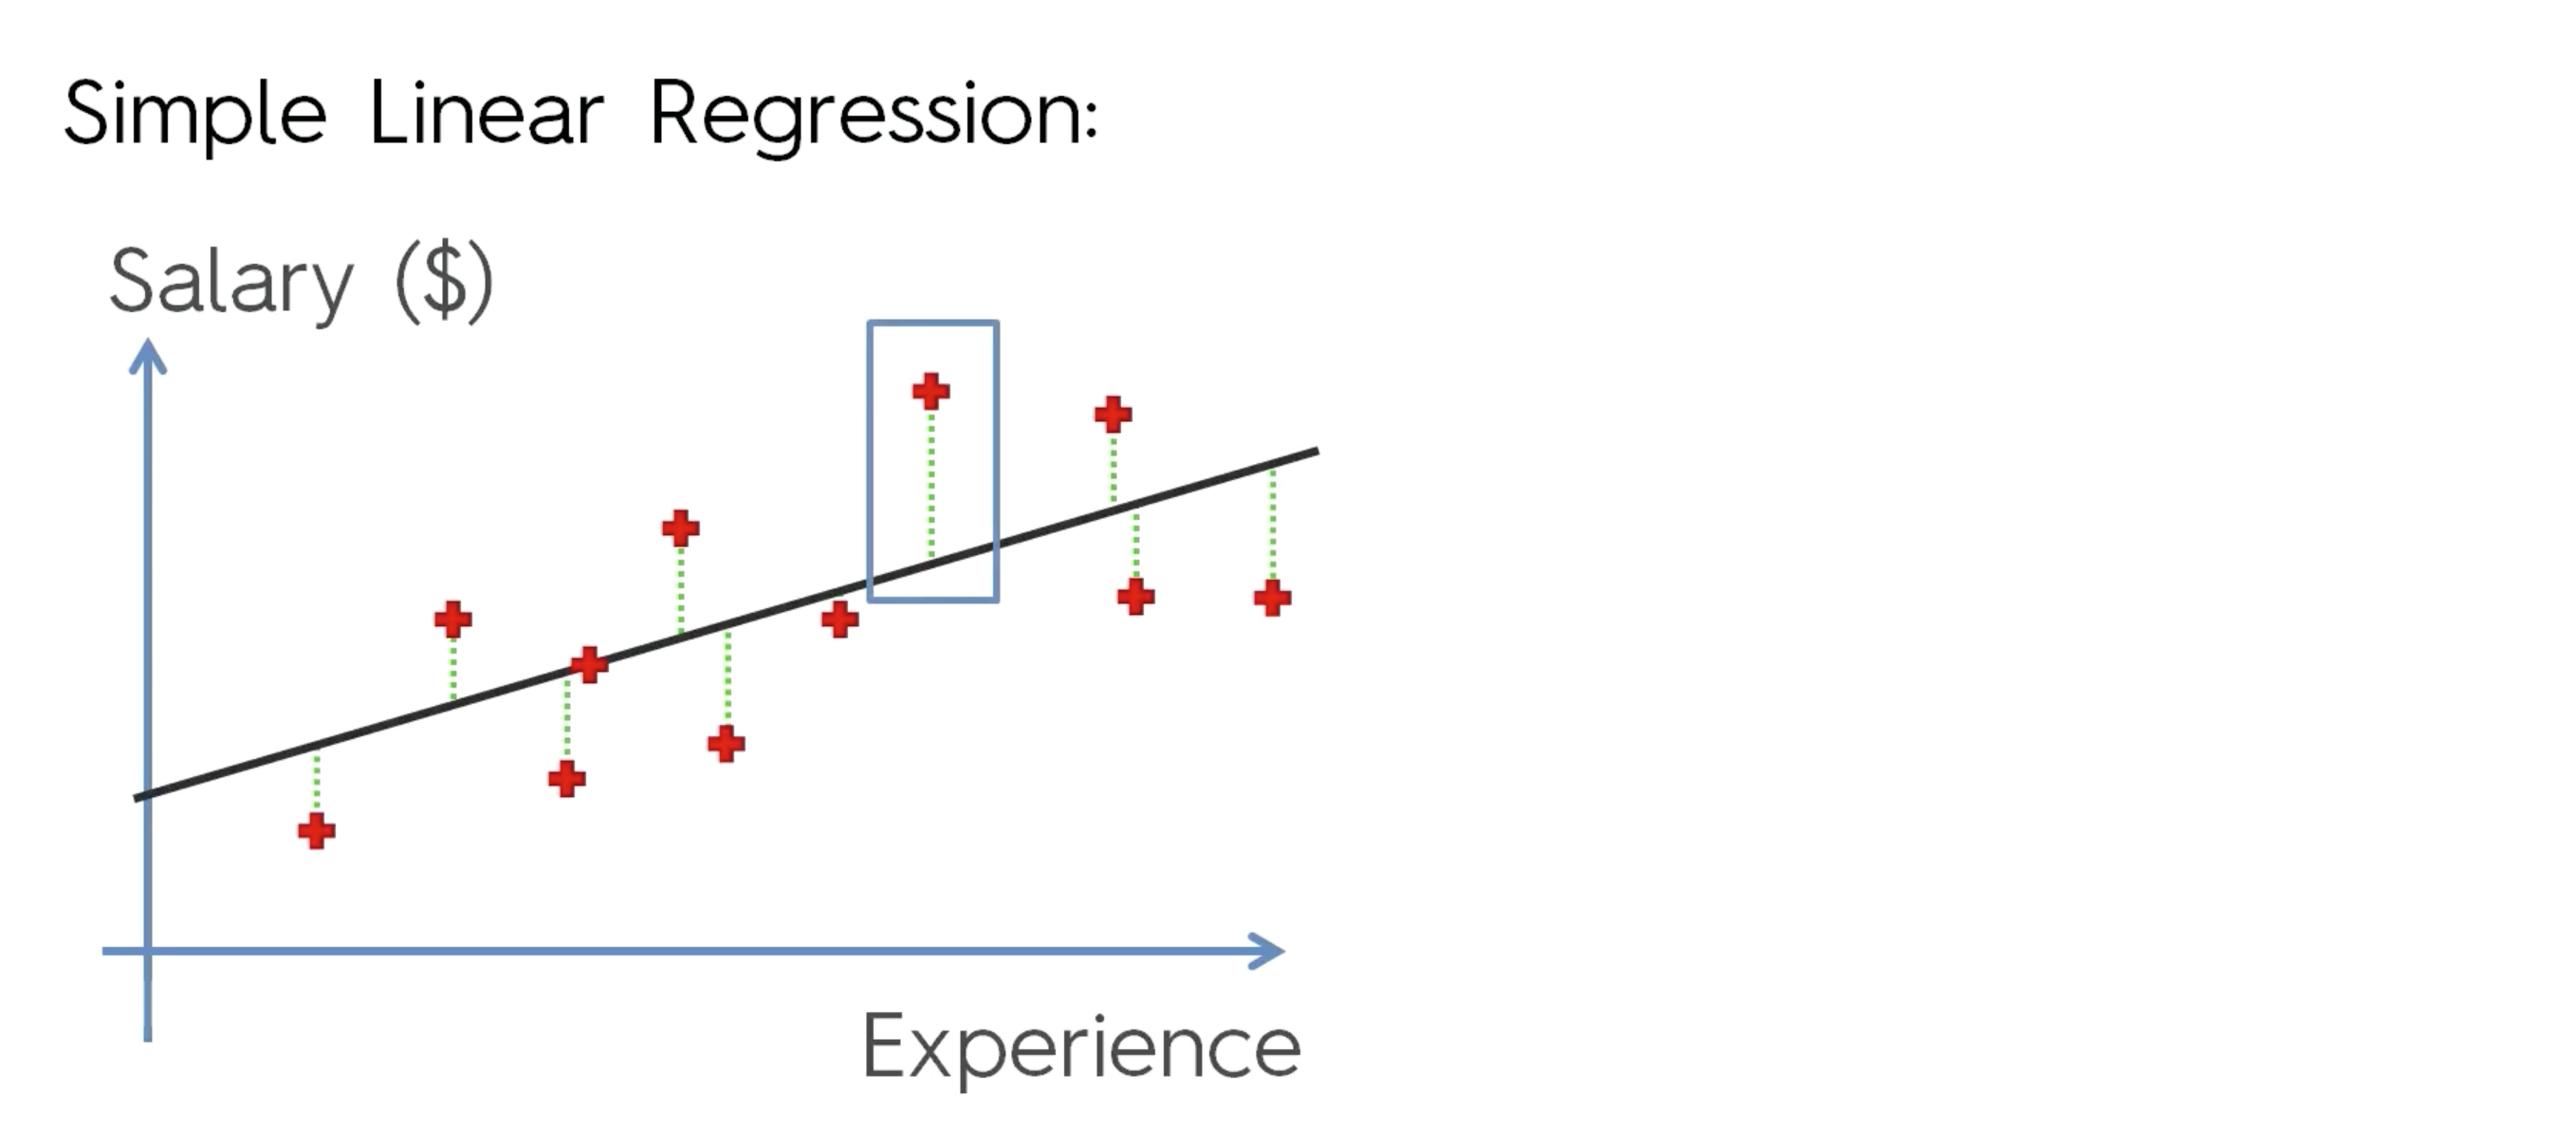

## 모든 관측점(Observation)에서의 y값의 error(오차)가 존재하고,  이 오차들의 총 합을 줄여 나가면 된다.

제곱을 하는 이유는?

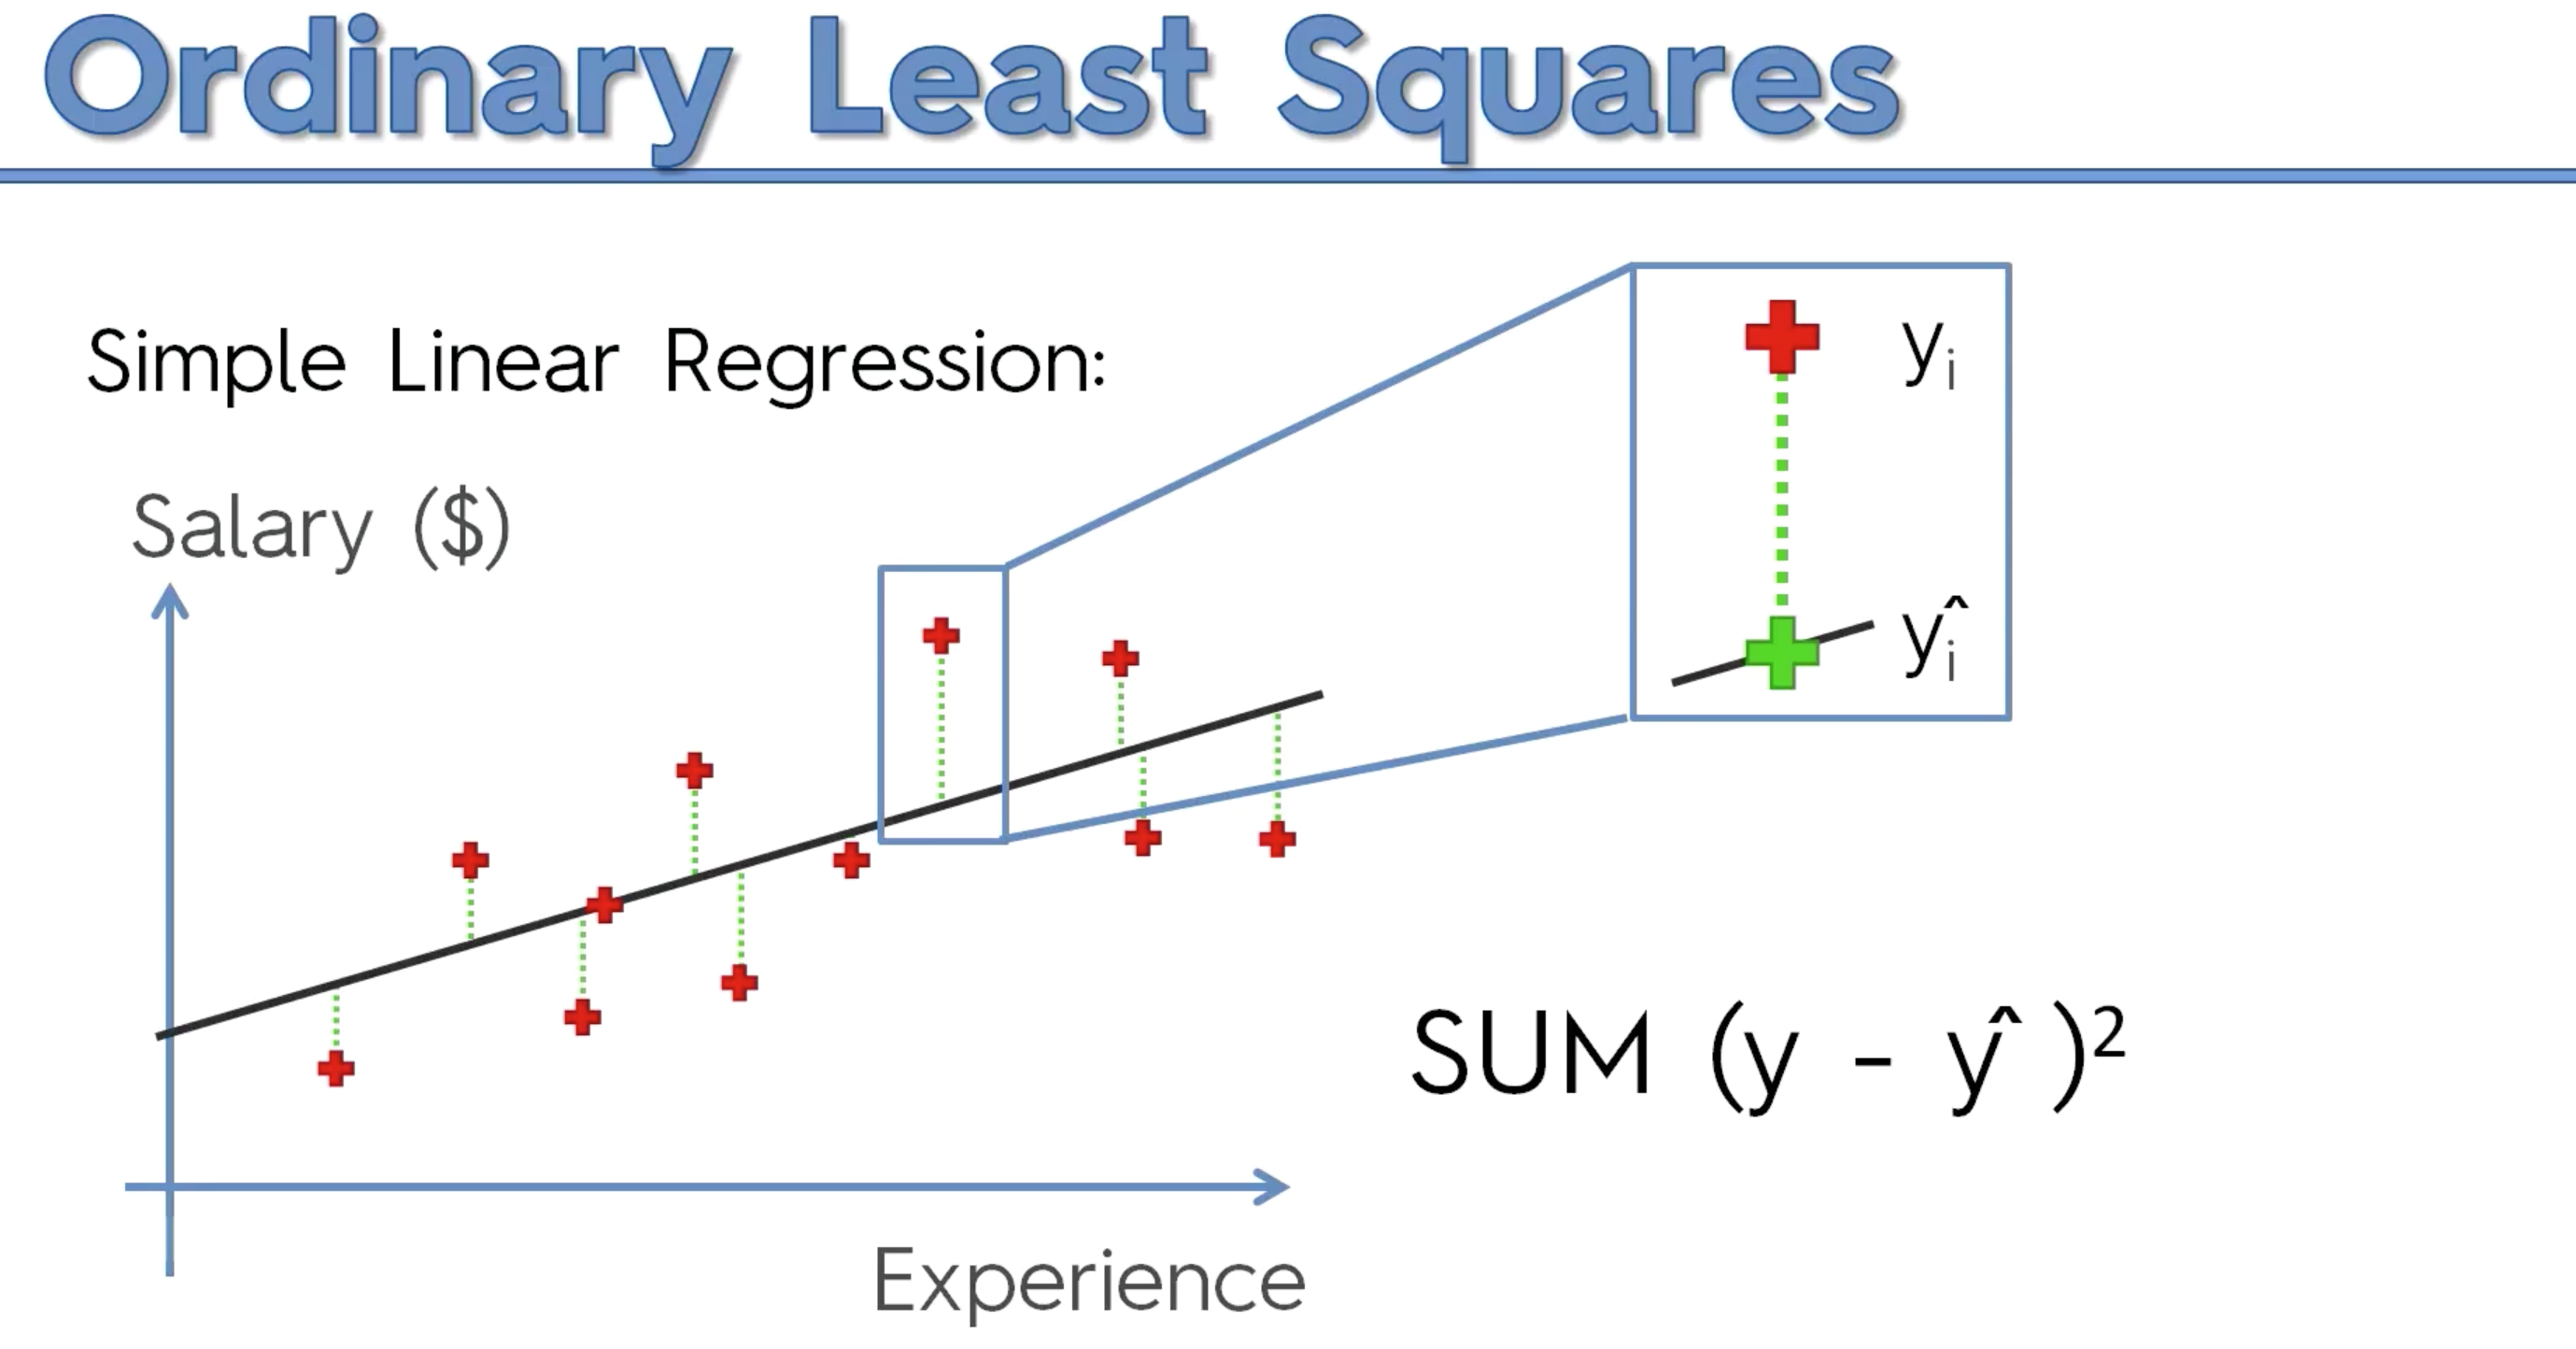

## 오차를 줄여 나가서, 최소값이 되는 직선을 찾으면 끝난다. 
- OLS(Ordinary Least Squares)란 일종의 선형 최소 최곱 방법
- 모든 값에 대해서 실제값과 관측값 사이의 오차를 제곱하여 모두 더하여 최소값이 되는 지점을 찾음

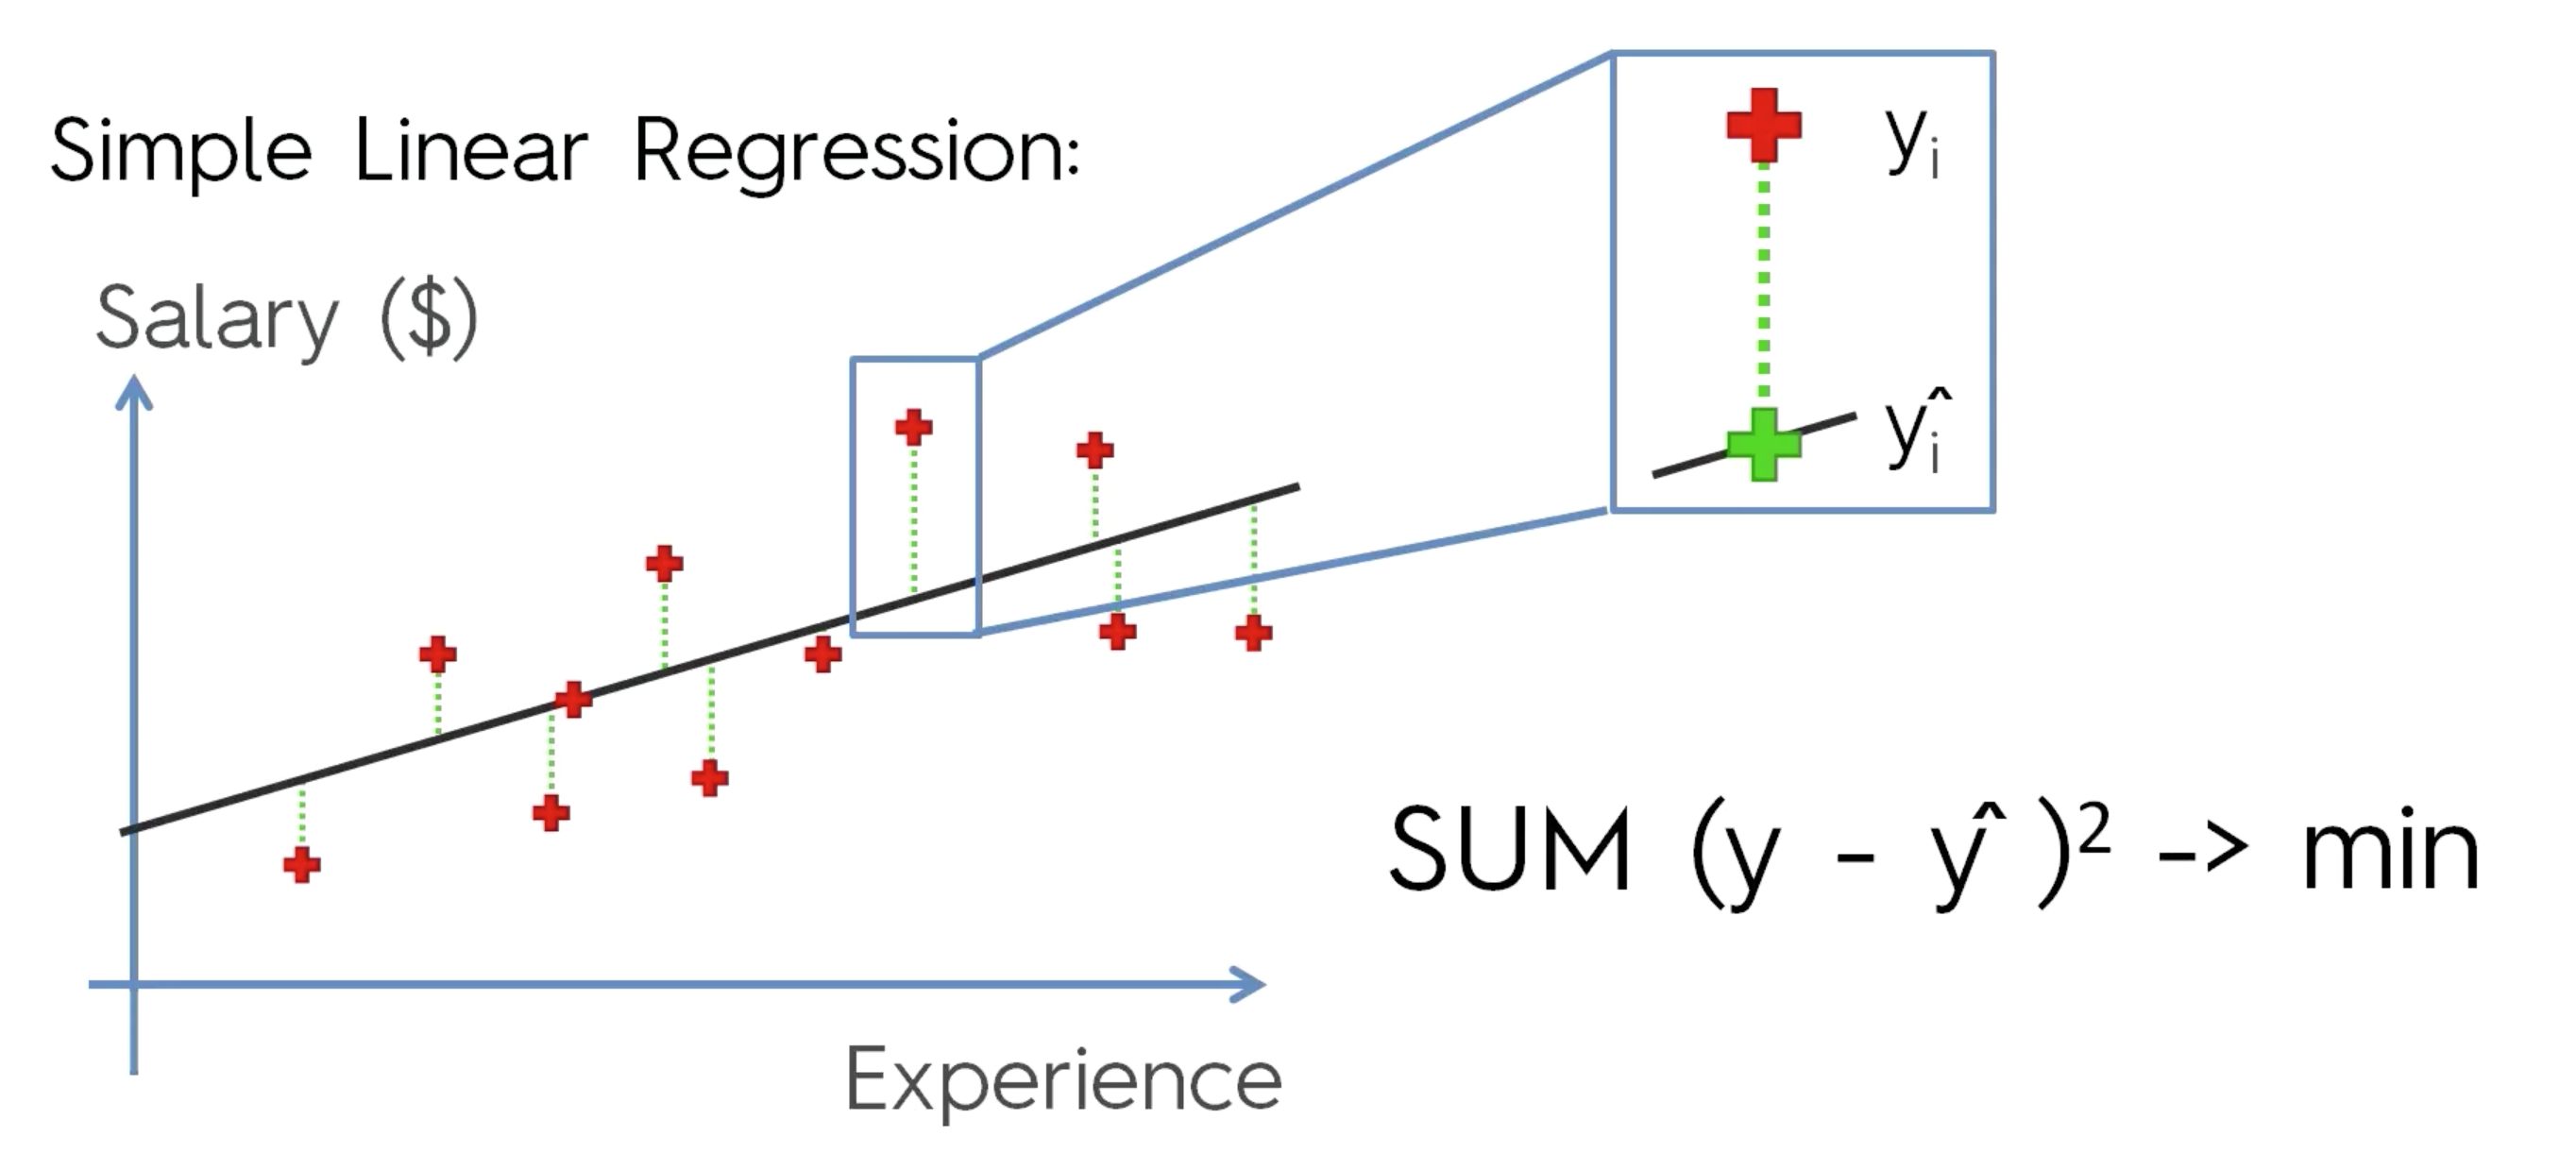

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Linear Regression 실습
- 실전 데이터로 머신러닝 모델 실습
- 'Salary_Data.csv' 를 읽으세요.

#### 경력과 연봉의 관계 분석을 통해, 누군가 입사했을 때, 그사람의 경력에 맞는 연봉을 제시해 줄 수 있도록 합니다.

## 데이터 준비

In [3]:
df = pd.read_csv('datas_ml/Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
# 결측치 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [5]:
# 우리가 예측하려고 하는 것은? 연봉

## x, y 데이터 분할

In [7]:
y = df['Salary']

In [9]:
x = df['YearsExperience']

In [10]:
y.shape

(30,)

In [11]:
x.shape

(30,)

In [ ]:
# x는 무조건 2차원이어야 함.
# x.to_frame() -> 2차원으로 변환
x = x.to_frame()
x.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


## 피처스케일링
- 독립변수 1개 이므로, 따로 해줄 필요 없다.
### 스케일링이 필요할 때
- 피처의 스케일 차이가 너무 크면
- 수치 불안정 → 계산 느림 → 가중치 해석 어려움

## 학습 데이터, 테스트 데이터 분할

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
# 학습용과 테스트용으로 나눔
train_test_split(x, y, test_size=0.2, random_state=7)

[    YearsExperience
 18              5.9
 24              8.7
 27              9.6
 29             10.5
 12              4.0
 13              4.1
 16              5.1
 0               1.1
 28             10.3
 6               3.0
 26              9.5
 20              6.8
 10              3.9
 21              7.1
 8               3.2
 14              4.5
 7               3.2
 23              8.2
 19              6.0
 3               2.0
 22              7.9
 25              9.0
 4               2.2
 15              4.9,
     YearsExperience
 2               1.5
 17              5.3
 1               1.3
 9               3.7
 11              4.0
 5               2.9,
 18     81363.0
 24    109431.0
 27    112635.0
 29    121872.0
 12     56957.0
 13     57081.0
 16     66029.0
 0      39343.0
 28    122391.0
 6      60150.0
 26    116969.0
 20     91738.0
 10     63218.0
 21     98273.0
 8      64445.0
 14     61111.0
 7      54445.0
 23    113812.0
 19     93940.0
 3      43525.0
 22   

In [16]:
# 대입 변수 순서가 중요함.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

In [17]:
x_train.shape, y_train.shape

((24, 1), (24,))

In [18]:
x_test.shape, y_test.shape

((6, 1), (6,))

## 모델 학습하기

In [17]:
# 연봉 예측 모델 만들기 => 예측 결과 숫자, 실수 숫자가 나오는 인공지능 만들기  => 회귀 regression

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
# 깡통 AI
lr_model = LinearRegression()

In [ ]:
# 학습 되기 전의 기울기
lr_model.coef_

# 아직 fit()을 하지 않아서 기울기가 존재하지 않음

AttributeError: 'LinearRegression' object has no attribute 'coef_'

In [ ]:
# 학습 되기 전의 절편 -> 아직 없음
lr_model.intercept_

AttributeError: 'LinearRegression' object has no attribute 'intercept_'

In [ ]:
# 회귀 모델 객체
lr_model


# 모델 객체 생성 확인

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 학습하기
- 문제(x)와 정답(y)를 넣어 학습하기

In [29]:
# 학습 데이터를 넣어서 학습
lr_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9554.27]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.496e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [30]:
# y = ax + b
# a, b를 찾는 거
# 기울기
lr_model.coef_

array([9554.2662031])

In [32]:
# 절편
lr_model.intercept_

np.float64(24964.822717686446)

## 모델 테스트

In [ ]:
# 테스트 데이터를 넣어, 결과 예측하기 -> fit에는 쓰지 않았던 데이터를 학습된 모델에 넣음
y_pred = lr_model.predict(x_test)
y_pred

array([39296.22202233, 75602.43359409, 37385.36878171, 60315.60766914,
       63181.88753007, 52672.19470666])

## 모델 평가
- 모델이 테스트한 결과(y_pred)와 실제값(y_test)의 오차의 제곱, 합의 평균 계산

In [34]:
# 정답
y_test

2     37731.0
17    83088.0
1     46205.0
9     57189.0
11    55794.0
5     56642.0
Name: Salary, dtype: float64

In [35]:
# 예측값
y_pred

array([39296.22202233, 75602.43359409, 37385.36878171, 60315.60766914,
       63181.88753007, 52672.19470666])

In [36]:
x_test

,YearsExperience
2,1.5
17,5.3
1,1.3
9,3.7
11,4.0
5,2.9


In [37]:
# 오차 제곱
(y_test - y_pred)**2


2     2.449920e+06
17    5.603370e+07
1     7.778589e+07
9     9.775676e+06
11    5.458088e+07
5     1.575935e+07
Name: Salary, dtype: float64

제곱을 하는 이유: 오차가 양수든 음수든 다 부호를 없애서 크기만 비교할 수 있게 하고, 큰 오차에 더 큰 페널티를 주기 위해서예요.

In [38]:
# 오차 : error의 제곱을 합한 후 데이터의 갯수로 나눔<- 오차제곱을 구한후 평균 구함 (MSE)
((y_test - y_pred)**2).mean() 

np.float64(36064238.49395526)

MSE (Mean Squared Error): 오차 제곱들의 평균. 값이 클수록 예측이 부정확하다는 뜻이지만, 단위가 원래 값의 제곱(연봉²)이라 직관적으로 해석하기 어려움.

In [39]:
# RMSE (MSE는 너무크기 때문에 RMS구함.)
np.sqrt(((y_test - y_pred)**2).mean())

np.float64(6005.350821888365)

RMSE (Root Mean Squared Error): MSE에 제곱근을 씌워서 단위를 원래 값(연봉)과 같게 맞춘 지표. "평균적으로 약 6005만큼 예측이 빗나갔다"고 해석 가능.

In [40]:
# MAE (절대값으로)
abs(y_test - y_pred).mean()

np.float64(5392.453356511897)

MAE (Mean Absolute Error): 오차에 제곱 대신 절대값을 씌운 뒤 평균. RMSE보다 이상치(outlier)의 영향을 덜 받는 지표.

핵심 포인트: 같은 오차 데이터를 가지고 MSE → RMSE → MAE 세 가지 방식으로 오차를 계산해보며, 각 지표가 어떤 의미와 특징을 갖는지(단위, 이상치 민감도) 비교해보는 섹션이에요. 세 값 모두 "작을수록 모델이 정확하다"는 공통점이 있습니다

## 오차를 시각적으로 확인하기

In [ ]:
df_test = y_test.to_frame()
#y_test(Series)를 DataFrame으로 변환. 컬럼명은 Salary 그대로 유지됨.

In [ ]:
df_test['y_pred'] = y_pred
# 예측값(y_pred)을 새 컬럼으로 추가해서, 실제값과 예측값을 한 표(DataFrame)에 나란히 둡니다.

In [43]:
df_test

,Salary,y_pred
2,37731.0,39296.222022
17,83088.0,75602.433594
1,46205.0,37385.368782
9,57189.0,60315.607669
11,55794.0,63181.887530
5,56642.0,52672.194707


인덱스가 2, 17, 1, 9, 11, 5처럼 뒤죽박죽인 이유는 train_test_split이 원본 데이터에서 무작위로 6개 행을 뽑았기 때문 (원래 인덱스가 그대로 남아있음).



## 실제값과 예측값의 차이 시각화

In [44]:
# 한글 깨짐 해결
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rc('axes', unicode_minus=False)     # 마이너스 깨짐 방지


In [46]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


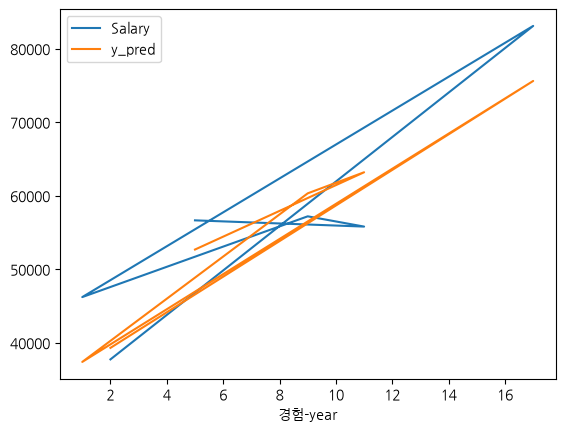

In [47]:
# 근무 년수에 따른 연봉 
df_test.plot(kind='line')
plt.xlabel("경험-year")
plt.show()

Salary(실제값)와 y_pred(예측값) 두 선을 하나의 꺾은선 그래프로 그려서 비교. 단, x축이 인덱스(2, 17, 1, 9...) 순서라 뒤죽박죽이라 보기 불편함.

In [48]:
# index reset하기
df_test = df_test.reset_index(drop=True)
df_test

,Salary,y_pred
0,37731.0,39296.222022
1,83088.0,75602.433594
2,46205.0,37385.368782
3,57189.0,60315.607669
4,55794.0,63181.887530
5,56642.0,52672.194707


그래서 인덱스를 0, 1, 2, 3, 4, 5로 재정렬(reset_index). drop=True는 기존 인덱스를 컬럼으로 남기지 않고 버린다는 뜻.

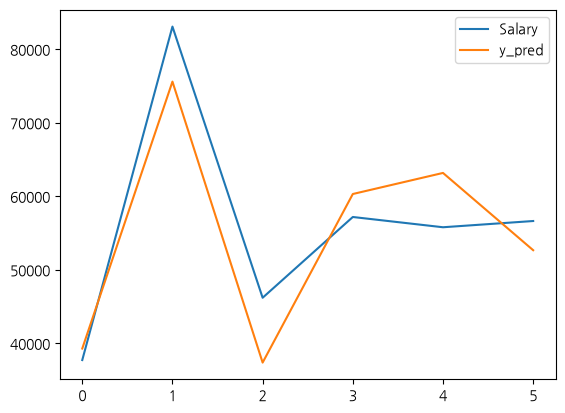

In [49]:
# 근무 년수에 따른 연봉 (꺽은선 그래프)
df_test.plot(kind='line')
plt.show()

인덱스를 정리한 뒤 다시 꺾은선 그래프로 실제값 vs 예측값을 비교. 두 선이 비슷하게 움직이면 모델 예측이 잘 됐다는 뜻.



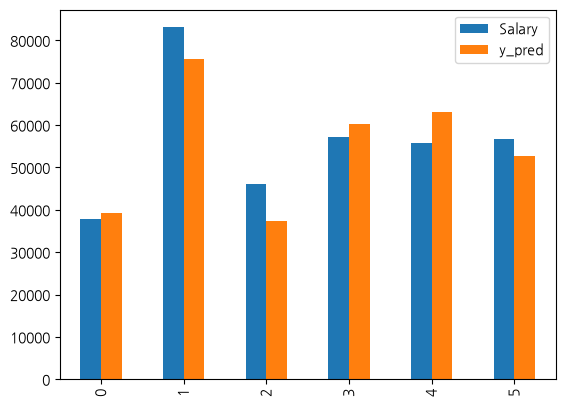

In [50]:
# 근무 년수에 따른 연봉 (막대그래프)
df_test.plot(kind='bar')
plt.show()

같은 데이터를 막대그래프로도 그려서, 각 테스트 샘플별로 실제값과 예측값 막대를 나란히 비교.

핵심 포인트: 숫자로 본 MSE/RMSE/MAE와 별개로, 실제값과 예측값을 표와 그래프(선/막대)로 나란히 놓고 눈으로 직접 오차 크기와 패턴을 확인하는 섹션이에요. 인덱스를 리셋해서 그래프 가독성을 높인 점도 포인트입니다